# 🏗️ Python Practice: Regression with K-Fold Cross-Validation and Hyperparameter Tuning

Welcome to this Machine Learning practice notebook! 🎉  
In this notebook, we will work with the **California Housing dataset** to explore regression workflows, compare models, and perform **hyperparameter tuning**.

You’ll learn to:
- Preprocess data and scale features
- Split data into **train/test sets**
- Use **K-Fold Cross-Validation** to evaluate multiple regression models
- Compare models such as **Linear Regression, Ridge, SVR, KNN, and Decision Tree**
- Tune hyperparameters using **GridSearchCV**
- Evaluate performance using **RMSE** and **R²**
- Interpret model results and compare different approaches

---

## 🧭 Instructions
- This notebook contains **5 exercises** plus **an optional challenge**.
- Each exercise includes **a task description**, **hints**, **solution cells**, **tests**, and **questions** for you to answer.
- Some exercises contain **questions** you should answer in a **new Markdown cell** below the question cell.
- Hints are available if you get stuck — take your time and explore!  
- You can run the tests as many times as needed.  
- Total estimated time: **90–120 minutes**.

---

## 🧠 Concepts Covered
- Loading datasets into Pandas
- Exploratory Data Analysis (EDA)
- Train/test split
- Feature scaling and preprocessing
- K-Fold Cross-Validation
- Comparing regression models: Linear Regression, Ridge, SVR, KNN, Decision Tree
- Hyperparameter tuning with GridSearchCV
- Evaluating models with RMSE and R²
- Interpreting model performance and hyperparameter effects

---

At the end of the notebook, there is an **optional challenge** for you to further experiment with model parameters and dimensionality reduction methods on a real-world dataset.  

Let’s begin your journey into **regression with K-Fold CV and hyperparameter tuning**! 🚀

## 🧩 Theory Recap: K-Fold Cross-Validation & Hyperparameter Tuning

### ⚙️ K-Fold Cross-Validation

When training a machine learning model, it is important to evaluate its performance **reliably**.  
A single train/test split can give **unstable results**, especially with small datasets or uneven distributions.

**K-Fold Cross-Validation (CV)** is a robust method:

1. Divide the dataset into **K equal parts (folds)**.  
2. For each fold:
   - Train the model on **K-1 folds**  
   - Test the model on the **remaining fold**  
3. Repeat until **every fold has been used as a test set**.  
4. Average the evaluation results to get a **more reliable estimate** of model performance.

#### Why it matters:
- Reduces variability caused by random train/test splits.  
- Provides a **better assessment of generalization** to unseen data.  
- Helps detect **underfitting or overfitting** early.

---

### 🔧 Hyperparameter Tuning

Most machine learning models have **hyperparameters** that control how the model learns:

| Model Type | Example Hyperparameters | Notes |
|:-----------|:----------------------|:------|
| **K-Nearest Neighbors (KNN)** | number of neighbors (`k`) | Controls how many nearby points influence the prediction |
| **Decision Tree** | maximum depth, minimum samples per leaf | Limits tree complexity to prevent overfitting |
| **Support Vector Machine (SVM)** | kernel type, regularization parameter (`C`) | Determines decision boundary shape and margin |
| **Neural Network** | learning rate, number of layers/neurons | Affects speed of learning and model capacity |

**Hyperparameter tuning** is the process of finding the **best combination of settings** for your model.  

**GridSearchCV** (or similar methods) automates this:

1. Define a **grid of possible hyperparameter values**.  
2. Train and evaluate the model across all combinations using **K-Fold CV**.  
3. Select the combination that performs **best according to your chosen metric**.

#### Why it matters:
- Prevents **overfitting or underfitting** due to poorly chosen parameters.  
- Ensures the model is **optimized for generalization**.  
- Allows **fair comparison** between different models.

---

### 🌍 General Principles

- K-Fold CV and hyperparameter tuning are **model-agnostic techniques** — they can be applied to **any supervised learning model**, whether regression or classification.  
- They improve the **reliability, fairness, and performance** of model evaluation.  
- Using both together gives a **robust framework** for selecting and tuning models before deploying them in real-world scenarios.

---

### 💡 Key Takeaways

- **K-Fold Cross-Validation** → provides stable and unbiased performance estimates.  
- **Hyperparameter tuning** → finds the best model configuration automatically.  
- These techniques are **essential for fair comparison and optimal generalization**.  
- Always consider these steps **before finalizing a model**, regardless of the algorithm.

In [12]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exercise 1: Exploratory Data Analysis of California Housing Dataset

In this task, you will load the **California Housing dataset** from `sklearn`.  
The dataset contains 20,640 samples with 8 features describing block-level demographics and housing information.  
The target variable is the **median house value** (`MedHouseVal`).

#### Your tasks:
- Load the dataset using `fetch_california_housing`.
- Convert it into a Pandas DataFrame for easier exploration.
- Display the **shape** of the dataset and the first few rows.
- Use `.describe()` to compute summary statistics of the features and target.
- Plot **histograms** of all features to check their distributions.
- Plot a **scatter plot** of each feature vs the target to explore relationships.

<details>
  <summary><strong>Click here for a hint!</strong></summary>
  <ul>
    <li> Use <code>from sklearn.datasets import fetch_california_housing</code> to load the data. </li>
    <li> Convert to a DataFrame: <code>pd.DataFrame(data, columns=feature_names)</code>. </li>
    <li> Add the target as a new column: <code>df['MedHouseVal'] = y</code>. </li>
    <li> Use <code>df.hist(figsize=(12,8))</code> to plot histograms. </li>
    <li> Use <code>sns.scatterplot(x='MedInc', y='MedHouseVal', data=df)</code> for scatter plots. </li>
  </ul>
</details>

X shape: (20640, 8)
y shape: (20640,)

First 5 rows of X:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Summary statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333

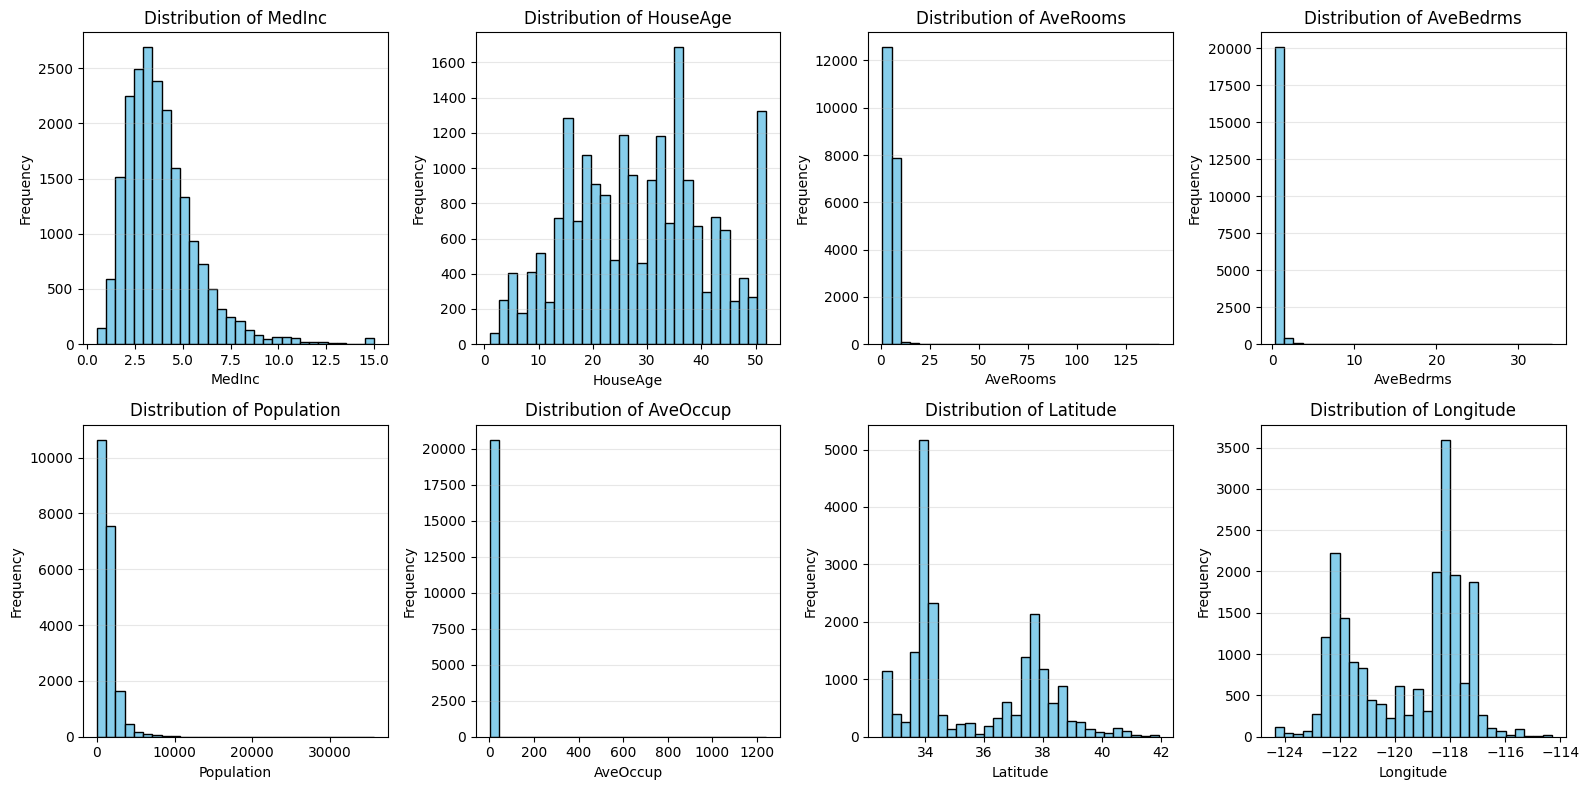

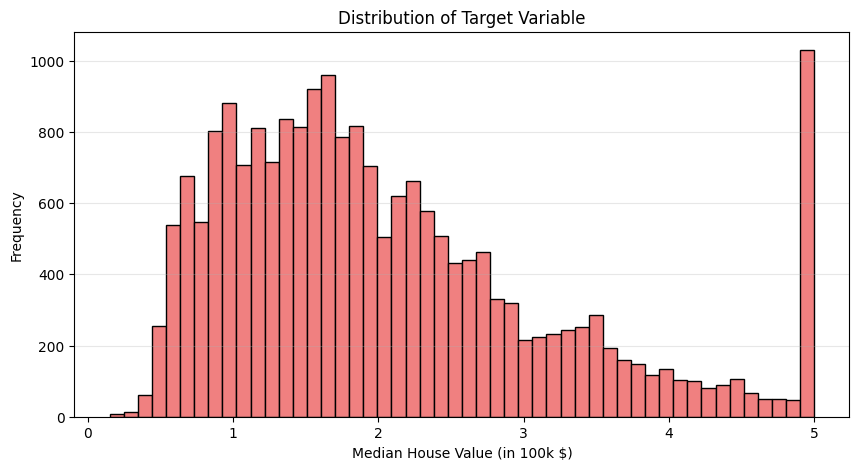

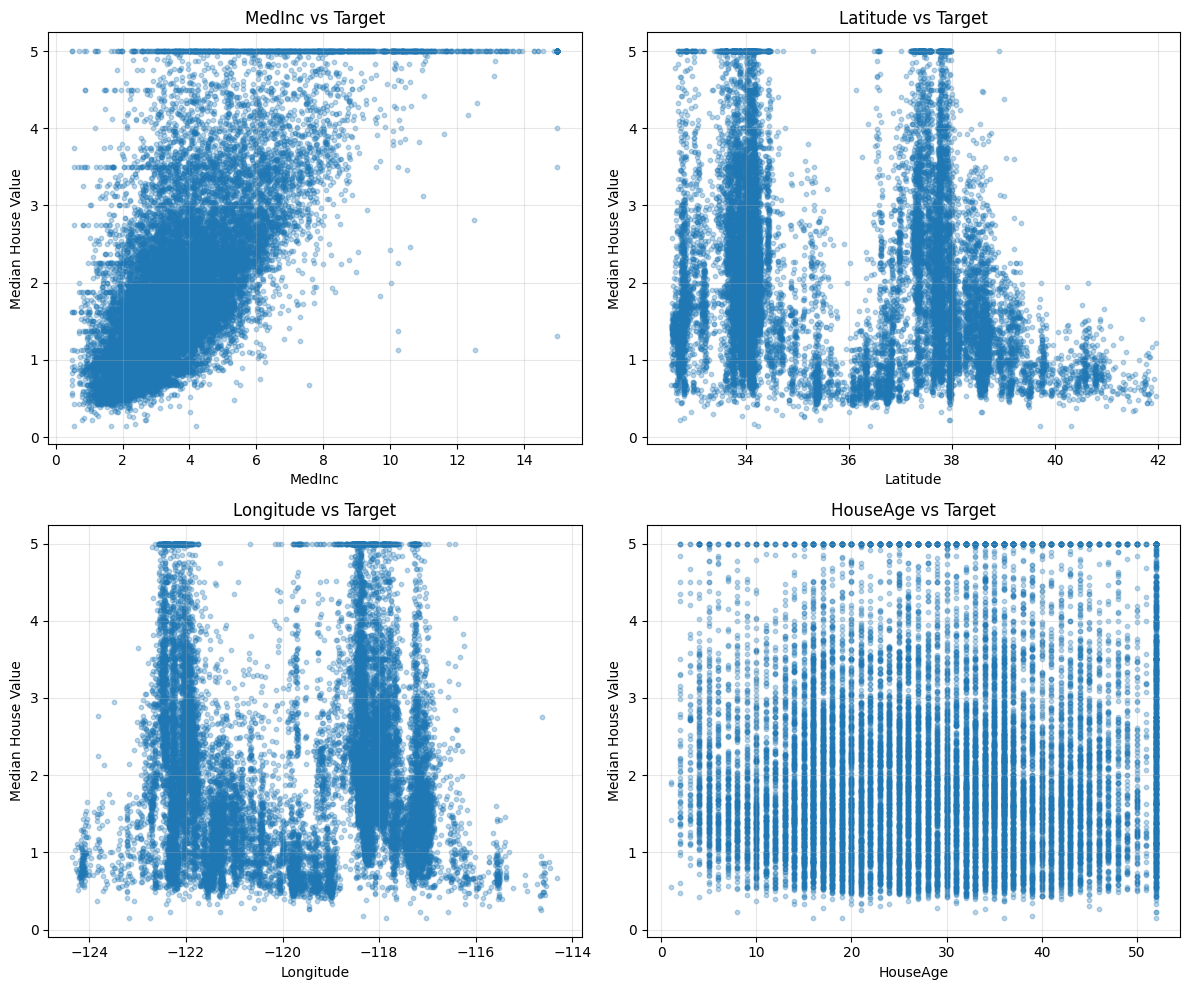

In [1]:
# Exercise 1: Exploratory Data Analysis
from sklearn.datasets import fetch_california_housing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load California Housing dataset
housing = fetch_california_housing()

# Convert to DataFrame
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target)

# Display shape and first rows
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFirst 5 rows of X:")
print(X.head())

# Summary statistics
print(f"\nSummary statistics:")
print(X.describe())

# Target statistics
print(f"\nTarget (Median House Value) statistics:")
print(y.describe())

# Plot histograms of all features
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for idx, col in enumerate(X.columns):
    axes[idx].hist(X[col], bins=30, color='skyblue', edgecolor='black')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Plot target variable
plt.figure(figsize=(10, 5))
plt.hist(y, bins=50, color='lightcoral', edgecolor='black')
plt.xlabel('Median House Value (in 100k $)')
plt.ylabel('Frequency')
plt.title('Distribution of Target Variable')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Scatter plots of features vs target (select a few key features)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

feature_pairs = [('MedInc', 0), ('Latitude', 1), ('Longitude', 2), ('HouseAge', 3)]

for idx, (feature_name, feature_idx) in enumerate(feature_pairs):
    ax = axes[idx // 2, idx % 2]
    ax.scatter(X[feature_name], y, alpha=0.3, s=10)
    ax.set_xlabel(feature_name)
    ax.set_ylabel('Median House Value')
    ax.set_title(f'{feature_name} vs Target')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
### BEGIN TESTS
df = X.copy()
df['MedHouseVal'] = y
assert df.shape == (20640, 9)
assert "MedHouseVal" in df.columns
assert df["MedHouseVal"].min() >= 0
assert df.iloc[0, 0] == housing.data[0, 0]
### END TESTS

### Questions
1. How many features are in the dataset, and what is the target variable?  
2. Which feature seems most correlated with the target based on scatter plots?  
3. Are any features skewed or have unusual distributions? How could this affect regression modeling?  

## Exercise 2: Train/Test Split and Scaling

Now that we have explored the dataset, we need to **split it into training and testing sets** and scale the features for regression models.

#### Your tasks:
- Split the data into **training (80%) and testing (20%)** sets using `train_test_split`.
- Use `random_state=42` for reproducibility.
- Apply a **StandardScaler** to the training features and transform both train and test sets.
- Store the results in `X_train_scaled`, `X_test_scaled`, `y_train`, `y_test`.
- Explain why **scaling is important** for some regression models (like Ridge or Lasso).

<details>
  <summary><strong>Click here for a hint!</strong></summary>
  <ul>
    <li> Use <code>from sklearn.model_selection import train_test_split</code> for splitting.</li>
    <li> Use <code>from sklearn.preprocessing import StandardScaler</code> for scaling.</li>
    <li> Fit the scaler only on <code>X_train</code> and transform both <code>X_train</code> and <code>X_test</code>.</li>
    <li> Scaling is important for models that are sensitive to feature magnitude (e.g., regularized linear models or KNN).</li>
  </ul>
</details>

In [5]:
# Exercise 2: Train/Test Split and Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Test target shape: {y_test.shape}")

# Apply StandardScaler (fit only on training data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nX_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

# Verify scaling (check mean and std of scaled data)
print(f"\nMean of scaled training data (should be ~0): {X_train_scaled.mean(axis=0)}")
print(f"Std of scaled training data (should be ~1): {X_train_scaled.std(axis=0)}")

print("\n" + "=" * 70)
print("IMPORTANCE OF SCALING FOR REGULARIZED MODELS:")
print("=" * 70)
print("""
- Regularized models (Ridge, Elastic Net, SVM, KNN) use distance-based metrics
- Features with different scales can dominate the regularization
- Scaling ensures all features contribute equally to the model
- LinearRegression doesn't require scaling, but Ridge/Elastic Net do
- StandardScaler: mean=0, std=1 (most common for standardization)
""")

Training set shape: (16512, 8)
Test set shape: (4128, 8)
Training target shape: (16512,)
Test target shape: (4128,)

X_train_scaled shape: (16512, 8)
X_test_scaled shape: (4128, 8)

Mean of scaled training data (should be ~0): [-6.41175313e-17 -1.67824411e-17  1.79012705e-16 -6.89371041e-16
  0.00000000e+00  1.03276560e-17  3.38574991e-15  1.77678716e-15]
Std of scaled training data (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]

IMPORTANCE OF SCALING FOR REGULARIZED MODELS:

- Regularized models (Ridge, Elastic Net, SVM, KNN) use distance-based metrics
- Features with different scales can dominate the regularization
- Scaling ensures all features contribute equally to the model
- LinearRegression doesn't require scaling, but Ridge/Elastic Net do
- StandardScaler: mean=0, std=1 (most common for standardization)



In [6]:
### BEGIN TESTS
assert X_train_scaled.shape[0] == 16512
assert X_test_scaled.shape[0] == 4128
assert X_train_scaled.shape[1] == 8
assert y_train.shape[0] == 16512
assert y_test.shape[0] == 4128
### END TESTS

### Questions
1. What would happen if we fit the scaler on the entire dataset instead of just the training set?

<details>
  <summary><strong>Click here for a hint!</strong></summary>
  <ul>
    <li> Use <code>pd.DataFrame(fold_scores)</code> to create a DataFrame. </li>
    <li> Use <code>seaborn.boxplot(data=scores_df)</code> to plot the boxplot. </li>
    <li> Label axes and add a title to make the plot informative. </li>
    <li> Rotating x-axis labels can help if the names are long: <code>plt.xticks(rotation=45)</code>. </li>
  </ul>
</details>

## Exercise 3: Fit Multiple Regression Models with 10-Fold Cross-Validation

In this task, you will **train several regression models** and evaluate them using **10-fold cross-validation** on the training data.

#### Your tasks:
- Use the following regression models from `sklearn`:
  - Linear Regression
  - Ridge Regression
  - K-Nearest Neighbors Regressor
  - Decision Tree Regressor
- Perform **10-fold cross-validation** (`KFold` or `cross_val_score`) on the **scaled training data**.
- Compute **RMSE** for each fold (use `neg_mean_squared_error` and take the square root).
- Store all fold scores in a dictionary called `cv_results` with model names as keys.
- Explain why using **10 folds** gives a better estimate of model performance.

<details>
  <summary><strong>Click here for a hint!</strong></summary>
  <ul>
    <li> Use <code>from sklearn.model_selection import KFold, cross_val_score</code>.</li>
    <li> Use <code>from sklearn.svm import SVR</code> for Support Vector Regression.</li>
    <li> Use <code>scoring='neg_mean_squared_error'</code> in <code>cross_val_score</code> to compute RMSE.</li>
    <li> Take the square root of negative scores: <code>np.sqrt(-scores)</code>.</li>
    <li> Store each model's fold RMSE scores in <code>cv_results[model_name]</code>.</li>
    <li> Using multiple folds reduces variance in the estimate and avoids overfitting to a single split.</li>
  </ul>
</details>

In [9]:
# Exercise 3: Multiple Regression Models with 10-Fold Cross-Validation
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

# Define models
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'DecisionTree': DecisionTreeRegressor(random_state=42)
}

# Store 10-fold CV results
cv_results = {}

# Perform 10-fold cross-validation for each model
for model_name, model in models.items():
    # Use negative MSE as scoring metric (scikit-learn convention)
    cv_scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=10,
        scoring='neg_mean_squared_error'
    )
    
    # Convert to RMSE
    rmse_scores = np.sqrt(-cv_scores)
    cv_results[model_name] = rmse_scores
    
    print(f"{model_name}:")
    print(f"  Mean RMSE: {rmse_scores.mean():.4f}")
    print(f"  Std RMSE: {rmse_scores.std():.4f}")
    print(f"  Min RMSE: {rmse_scores.min():.4f}")
    print(f"  Max RMSE: {rmse_scores.max():.4f}\n")

print("=" * 70)
print("ADVANTAGES OF 10-FOLD CROSS-VALIDATION:")
print("=" * 70)
print("""
- More stable estimates: averages performance across 10 splits
- Better use of data: each sample is used for both training and validation
- Reduces variance in performance estimates
- 10 folds is a good balance between bias and computational cost
- Helps detect overfitting by comparing train/test performance
""")

LinearRegression:
  Mean RMSE: 0.7205
  Std RMSE: 0.0236
  Min RMSE: 0.6849
  Max RMSE: 0.7551

Ridge:
  Mean RMSE: 0.7205
  Std RMSE: 0.0235
  Min RMSE: 0.6849
  Max RMSE: 0.7551

KNN:
  Mean RMSE: 0.6469
  Std RMSE: 0.0210
  Min RMSE: 0.6212
  Max RMSE: 0.6945

DecisionTree:
  Mean RMSE: 0.7306
  Std RMSE: 0.0272
  Min RMSE: 0.6883
  Max RMSE: 0.7750

ADVANTAGES OF 10-FOLD CROSS-VALIDATION:

- More stable estimates: averages performance across 10 splits
- Better use of data: each sample is used for both training and validation
- Reduces variance in performance estimates
- 10 folds is a good balance between bias and computational cost
- Helps detect overfitting by comparing train/test performance



In [10]:
### BEGIN TESTS
assert isinstance(cv_results, dict)
assert all(len(scores) == 10 for scores in cv_results.values())
for name in ["LinearRegression", "Ridge", "KNN", "DecisionTree"]:
    assert name in cv_results
    assert all(score >= 0 for score in cv_results[name])
### END TESTS

### Questions
1. Why do we use K-Fold cross-validation instead of a single train/validation split?  
2. Which models are sensitive to feature scaling, and why?  
3. How could the RMSE vary across folds for different models? What does it indicate about model stability?

## Exercise 4: Compare Models with Boxplot of Fold RMSE

Now that we have the **10-fold RMSE scores** for each regression model, we will **visualize their performance** using a boxplot.  

#### Your tasks:
- Create a **Pandas DataFrame** from `cv_results` so that each column corresponds to a model and each row is a fold.
- Plot a **boxplot** of the fold RMSEs for all models using `seaborn` or `matplotlib`.
- Analyze which model seems **most stable** (smallest spread) and which has the **lowest median RMSE**.
- Explain why **boxplots** are useful for comparing cross-validation results.

<details>
  <summary><strong>Click here for a hint!</strong></summary>
  <ul>
    <li> Convert `cv_results` to a DataFrame: <code>pd.DataFrame(cv_results)</code>.</li>
    <li> Use <code>sns.boxplot(data=df)</code> to plot fold RMSEs.</li>
    <li> The median line in the boxplot shows typical performance; the box shows interquartile range (spread).</li>
    <li> Models with smaller spread are more stable across folds.</li>
  </ul>
</details>

CV Results DataFrame:
       LinearRegression      Ridge        KNN  DecisionTree
count         10.000000  10.000000  10.000000     10.000000
mean           0.720473   0.720472   0.646948      0.730623
std            0.024828   0.024823   0.022158      0.028712
min            0.684924   0.684937   0.621167      0.688276
25%            0.697909   0.697921   0.631301      0.715662
50%            0.729351   0.729332   0.643504      0.734193
75%            0.736880   0.736885   0.655206      0.743914
max            0.755138   0.755133   0.694519      0.774954

Summary Statistics:
                  Mean RMSE  Std RMSE  Min RMSE  Max RMSE
LinearRegression   0.720473  0.024828  0.684924  0.755138
Ridge              0.720472  0.024823  0.684937  0.755133
KNN                0.646948  0.022158  0.621167  0.694519
DecisionTree       0.730623  0.028712  0.688276  0.774954


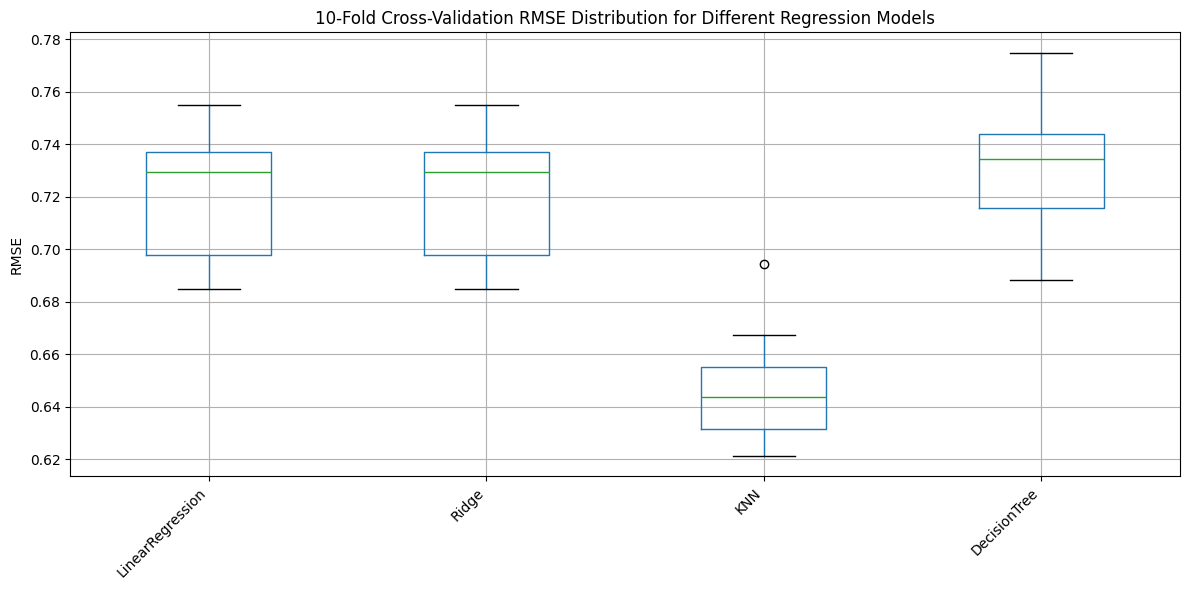


MODEL COMPARISON RESULTS
Model with lowest median RMSE: KNN (0.6435)
Most stable model (lowest std): KNN (0.0222)

WHY BOXPLOTS ARE USEFUL FOR COMPARING CV RESULTS:

- Show distribution of scores across all folds
- Reveal outliers and variance in model performance
- Easy comparison of median and quartiles across models
- Identify stable vs. unstable models visually
- Better than just looking at mean values



In [11]:
# Exercise 4: Compare Models with Boxplot of Fold RMSE
# Convert cv_results to DataFrame for easier manipulation
cv_df = pd.DataFrame(cv_results)

print("CV Results DataFrame:")
print(cv_df.describe())

# Calculate summary statistics
summary_stats = pd.DataFrame({
    'Mean RMSE': cv_df.mean(),
    'Std RMSE': cv_df.std(),
    'Min RMSE': cv_df.min(),
    'Max RMSE': cv_df.max()
})

print("\nSummary Statistics:")
print(summary_stats)

# Create boxplot visualization
plt.figure(figsize=(12, 6))
cv_df.boxplot(grid=True)
plt.ylabel('RMSE')
plt.title('10-Fold Cross-Validation RMSE Distribution for Different Regression Models')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Identify best model
best_model_name = cv_df.mean().idxmin()
best_median = cv_df.median()[best_model_name]
most_stable = cv_df.std().idxmin()

print("\n" + "=" * 70)
print("MODEL COMPARISON RESULTS")
print("=" * 70)
print(f"Model with lowest median RMSE: {best_model_name} ({best_median:.4f})")
print(f"Most stable model (lowest std): {most_stable} ({cv_df.std()[most_stable]:.4f})")

print("\n" + "=" * 70)
print("WHY BOXPLOTS ARE USEFUL FOR COMPARING CV RESULTS:")
print("=" * 70)
print("""
- Show distribution of scores across all folds
- Reveal outliers and variance in model performance
- Easy comparison of median and quartiles across models
- Identify stable vs. unstable models visually
- Better than just looking at mean values
""")

In [12]:
### BEGIN TESTS
assert isinstance(cv_df, pd.DataFrame)
assert set(cv_df.columns) == {"LinearRegression", "Ridge", "KNN", "DecisionTree"}
assert cv_df.shape[0] == 10  # 10 folds
assert cv_df.min().min() >= 0
### END TESTS

### Questions
1. Which model has the lowest median RMSE? Which model has the largest spread across folds?  
2. Why might a model have low median RMSE but high variability across folds?  
3. How can this visualization help in selecting a regression model?

## Exercise 5: Hyperparameter Search for Decision Tree Regressor

Now we will perform **hyperparameter tuning** for the Decision Tree Regressor.

#### Your tasks:
- Use `DecisionTreeRegressor` as the base model.
- Define a **parameter grid**:
  - `max_depth`: [None, 5, 10, 15]
  - `min_samples_split`: [2, 5, 10]
  - `min_samples_leaf`: [1, 2, 4]
- Use `GridSearchCV` with **10-fold cross-validation** on the **scaled training data**.
- Fit the model with the **best parameters**.
- Evaluate the tuned Decision Tree on the **test set** using **RMSE** and **R²**.
- Explain why **cross-validation** is important for hyperparameter tuning.

<details>
  <summary><strong>Click here for a hint!</strong></summary>
  <ul>
    <li> Use <code>from sklearn.tree import DecisionTreeRegressor</code> and <code>from sklearn.model_selection import GridSearchCV</code>.</li>
    <li> Pass <code>cv=10</code> and <code>scoring='neg_mean_squared_error'</code> to GridSearchCV.</li>
    <li> Take the square root of negative scores to get RMSE.</li>
    <li> Fit the GridSearchCV object on <code>X_train_scaled</code> and <code>y_train</code>.</li>
    <li> Evaluate the final model on <code>X_test_scaled</code> using <code>predict</code>.</li>
  </ul>
</details>

In [13]:
# Exercise 5: Hyperparameter Search for Decision Tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Define parameter grid for Decision Tree
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create base Decision Tree regressor
dt = DecisionTreeRegressor(random_state=42)

# GridSearchCV with 10-fold cross-validation
grid_search = GridSearchCV(
    dt, param_grid,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

print("Running GridSearchCV (this may take a moment)...")
grid_search.fit(X_train_scaled, y_train)

best_params = grid_search.best_params_

print("\n" + "=" * 70)
print("GRIDSEARCHCV RESULTS")
print("=" * 70)
print(f"Best parameters: {best_params}")
print(f"Best CV RMSE: {np.sqrt(-grid_search.best_score_):.4f}")

# Evaluate tuned model on test set
y_pred_test = grid_search.best_estimator_.predict(X_test_scaled)

# Calculate RMSE and R² on test set
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2 = r2_score(y_test, y_pred_test)

print(f"\nTest Set Performance:")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  R² Score: {test_r2:.4f}")

# Compare with untuned Decision Tree
dt_untuned = DecisionTreeRegressor(random_state=42)
dt_untuned.fit(X_train_scaled, y_train)
y_pred_untuned = dt_untuned.predict(X_test_scaled)
rmse_untuned = np.sqrt(mean_squared_error(y_test, y_pred_untuned))
r2_untuned = r2_score(y_test, y_pred_untuned)

print(f"\nUntuned Decision Tree Performance:")
print(f"  RMSE: {rmse_untuned:.4f}")
print(f"  R² Score: {r2_untuned:.4f}")

print(f"\nImprovement from tuning:")
print(f"  RMSE reduction: {rmse_untuned - test_rmse:.4f}")
print(f"  R² improvement: {test_r2 - r2_untuned:.4f}")

print("\n" + "=" * 70)
print("IMPORTANCE OF CV FOR HYPERPARAMETER TUNING:")
print("=" * 70)
print("""
- CV prevents overfitting to a single train/test split
- Provides robust estimates of model performance
- Ensures selected hyperparameters generalize well
- Reduces chance of lucky parameters that only work for one split
- Standard practice in machine learning pipelines
""")

Running GridSearchCV (this may take a moment)...
Fitting 10 folds for each of 36 candidates, totalling 360 fits

GRIDSEARCHCV RESULTS
Best parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV RMSE: 0.6277

Test Set Performance:
  RMSE: 0.6387
  R² Score: 0.6887

Untuned Decision Tree Performance:
  RMSE: 0.7028
  R² Score: 0.6230

Improvement from tuning:
  RMSE reduction: 0.0642
  R² improvement: 0.0657

IMPORTANCE OF CV FOR HYPERPARAMETER TUNING:

- CV prevents overfitting to a single train/test split
- Provides robust estimates of model performance
- Ensures selected hyperparameters generalize well
- Reduces chance of lucky parameters that only work for one split
- Standard practice in machine learning pipelines



In [14]:
### BEGIN TESTS
assert hasattr(grid_search, "best_estimator_")
assert isinstance(best_params, dict)
assert "max_depth" in best_params and "min_samples_split" in best_params and "min_samples_leaf" in best_params
assert test_rmse >= 0
assert -1 <= test_r2 <= 1
### END TESTS

### Questions
1. Why is cross-validation important when tuning hyperparameters?  
2. How do the parameters `max_depth`, `min_samples_split`, and `min_samples_leaf` affect bias and variance?  
3. Why do we evaluate the final model on a separate test set instead of using the CV results directly?

## Challenge: Lonpestia Language Identification

As an extra challenge, you can try the following problem, which comes directly from the course:

- Visit the task at: [Lonpestia Language Identification Challenge](https://judge.nitro-ai.org/cram-school/cram-school-preonia-2025/problems/2/task)
- The goal is to predict the language of a given text using machine learning.
- This is an **optional challenge** for students to experiment further:
    - Try different **model hyperparameters**.
    - Apply **dimensionality reduction techniques** (e.g., PCA, t-SNE) if helpful.
    - Explore preprocessing and feature extraction strategies.
- This exercise encourages you to apply the knowledge gained in the notebook to a **real-world problem** and fine-tune your models for better performance.